# Partial correlation longitudinal

## Purpose

Compute partial correlation between metrics and UPDRS score longitudinal.
Metrics are cortical thickness, area, volume and subcortical volume.

- UPDRS score change: $T_2 - T_1$
- Metric rate change: $\left| \dfrac{T_2-T_1}{T_1}\right|$


## Definition

Pingouin [method](https://pingouin-stats.org/build/html/generated/pingouin.partial_corr.html#pingouin.partial_corr)

Partial correlation [1] measures the degree of association between x and y, after removing the effect of one or more controlling variables (covar or $Z$). Practically, this is achieved by calculating the correlation coefficient between the residuals of two linear regressions:

$$x \sim Z, y \sim Z$$

Like the correlation coefficient, the partial correlation coefficient takes on a value in the range from –1 to 1, where 1 indicates a perfect positive association.

The semipartial correlation is similar to the partial correlation, with the exception that the set of controlling variables is only removed for either x or y, but not both.

Pingouin uses the method described in [2] to calculate the (semi)partial correlation coefficients and associated p-values. This method is based on the inverse covariance matrix and is significantly faster than the traditional regression-based method. Results have been tested against the ppcor R package.

## Get info about subjects

In [1]:
from IPython.display import display, Image

STATIC_RENDERING = True


# This is a static rendering of the notebook.
def show_figure(fig):
    if STATIC_RENDERING:
        img = fig.to_image(format="png")
        display(Image(img))
    else:
        fig.show()


In [2]:
%load_ext cudf.pandas
import pandas as pd
from IPython.display import display
import os
from tqdm import tqdm
from pathlib import Path

import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*column_view.*")

root_dir = os.path.dirname(os.getcwd())  # Use current working directory as root_dir
display("Running in root dir: ", os.path.basename(root_dir))
stats_dir = Path(root_dir) / "stats_QCed" / "sampled"
print("Stats directory:", stats_dir)

output_dir = Path() / "partial_correlation"
output_dir.mkdir(parents=True, exist_ok=True)
print("Output directory:", output_dir.absolute())


'Running in root dir: '

'freesurfer-fuzzy'

Stats directory: /mnt/lustre/ychatel/living-park/VIP-python-client/example/freesurfer-fuzzy/stats_QCed/sampled
Output directory: /mnt/lustre/ychatel/living-park/VIP-python-client/example/freesurfer-fuzzy/notebooks/partial_correlation


In [3]:
def get_clinical_long_pcorr():
    df_clinical = pd.read_csv("../pd_clinical.csv")
    print(f"Load cohort stats: {os.path.abspath('../pd_clinical.csv')}")
    columns = [
        "PATNO",
        "first_visit",
        "second_visit",
        "dx_group",
        "SEX",
        "AGE_AT_VISIT",
        "UPDRS_change",
        "durationT2_T1_y",
    ]
    df_clinical["first_visit"] = (
        "sub-"
        + df_clinical["PATNO"].astype(str)
        + "_ses-"
        + df_clinical["EVENT_ID"].astype(str)
    )
    df_clinical["second_visit"] = (
        "sub-"
        + df_clinical["PATNO"].astype(str)
        + "_ses-"
        + df_clinical["NEXT_VISIT"].astype(str)
    )
    df_clinical = df_clinical[df_clinical.dx_group == "PD-non-MCI"]
    df_clinical.rename(columns={"NP3TOT_change": "UPDRS_change"}, inplace=True)
    print(f"Number of PD-non-MCI subjects: {df_clinical.shape[0]}")
    return df_clinical[columns]


df_clinical = get_clinical_long_pcorr()

Load cohort stats: /mnt/lustre/ychatel/living-park/VIP-python-client/example/freesurfer-fuzzy/pd_clinical.csv
Number of PD-non-MCI subjects: 119


In [4]:
def assert_number_of_repetitions(df, hemisphere=None, repetitions=26):
    """
    Assert that each subjects/region has exactly N repetitions.
    """
    groups = ["subjects", "region"] + (["hemisphere"] if hemisphere else [])
    grouped = df.groupby(groups).count() == repetitions
    assert grouped.all().all(), (
        f"Not all subjects/regions have {repetitions} repetitions. {grouped[grouped == False].count()}"
    )

## Code
### Create longitudinal dataframe

In [ ]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")


def get_visit_at_metric_df(metric, visit, hemisphere, cohort_df, force=False):
    """
    Get baseline dataframe for a specific metric with enhanced performance and error handling.

    Parameters:
    -----------
    metric : str
        The name of the metric to retrieve
    hemisphere : bool
        Whether to include hemisphere information
    cohort_df : pandas.DataFrame
        Clinical cohort dataframe
    force : bool, default=False
        If True, regenerate the dataframe even if it exists on disk

    Returns:
    --------
    pd.DataFrame
        A dataframe containing the metric values and associated data
    """
    try:
        # Validate visit parameter
        if visit not in [1, 2]:
            raise ValueError("Visit must be 1 or 2")

        # Determine visit name
        visit_name = "baseline" if visit == 1 else "longitudinal"

        # Check for cached file first
        filename = (
            output_dir / f"partial_correlation_visit-{visit_name}_df_{metric}.parquet"
        )

        if filename.exists() and not force:
            print(f"📁 Loading cached baseline data for {metric}...")
            df = pd.read_parquet(filename)
            return df

        print(f"🔄 Creating visit-{visit_name} dataframe for {metric}...")

        # Load and process data with error handling
        df = pd.read_parquet(stats_dir / f"{metric}.parquet")

        # Drop column if it exists
        if "PATNO_id" in df.columns:
            df = df.drop(columns=["PATNO_id"])
        if hemisphere:
            df.rename(columns={"hemi": "hemisphere"}, inplace=True)

        # Optimize repetition numbering
        print("🔄 Optimizing repetition numbering...")
        df["repetition"] = (
            df.groupby(["subjects"] + (["hemisphere"] if hemisphere else [])).cumcount()
            + 1
        )

        # Melt operation to reshape dataframe
        print(f"🔄 Reshaping data for {len(df)} records...")

        # Define ID columns based on hemisphere flag
        id_vars = ["repetition", "subjects", "dx_group", "PD_status"] + (
            ["hemisphere"] if hemisphere else []
        )
        df = df.melt(id_vars=id_vars, var_name="region", value_name=metric)

        # Clean region names
        df["region"] = df["region"].str.replace(f"_{metric}", "", regex=False)

        assert_number_of_repetitions(df, hemisphere=hemisphere)

        # Merge with clinical data
        print("🔄 Merging with clinical data...")
        visit_col = "first_visit" if visit == 1 else "second_visit"
        clinical_columns = [
            visit_col,
            "AGE_AT_VISIT",
            "SEX",
            "UPDRS_change",
            "durationT2_T1_y",
        ]

        merged_df = pd.merge(
            df,
            cohort_df[clinical_columns],
            left_on="subjects",
            right_on=visit_col,
            how="inner",
        )

        print(f"✅ Successfully merged {len(merged_df)} clinical records")

        # Clean up data types
        numeric_cols = [metric, "AGE_AT_VISIT", "UPDRS_change", "durationT2_T1_y"]
        for col in numeric_cols:
            if col in merged_df.columns:
                merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")

        # Save results
        print(f"💾 Saving baseline dataframe to {filename}...")
        merged_df.to_parquet(filename)

        print(f"✅ Created baseline dataframe with {len(merged_df)} records")
        return merged_df

    except Exception as e:
        print(f"❌ Error creating baseline dataframe: {e}")
        raise


def compute_partial_correlation(change_df, metric, hemisphere, force=False):
    """
    Compute partial correlation with enhanced error handling and performance.

    Parameters:
    -----------
    change_df : pandas.DataFrame
        Baseline dataframe with metric values
    metric : str
        The metric name
    hemisphere : bool
        Whether hemisphere information is included
    force : bool, default=False
        Force recomputation even if cached file exists

    Returns:
    --------
    pandas.DataFrame
        Partial correlation results
    """
    import pingouin as pg

    try:
        # Check for cached results
        filename = output_dir / f"partial_correlation_longitudinal_{metric}.parquet"
        if os.path.exists(filename) and not force:
            print(f"📁 Loading cached partial correlation results for {metric}...")
            df = pd.read_parquet(filename)
            return df

        print(f"🧮 Computing partial correlations for {metric}...")

        # Validate required columns
        required_cols = [
            metric,
            "UPDRS_change",
            "AGE_AT_VISIT",
            "SEX",
            "repetition",
            "region",
            "durationT2_T1_y",
        ]
        if hemisphere:
            required_cols.append("hemisphere")

        missing_cols = [col for col in required_cols if col not in change_df.columns]
        if missing_cols:
            raise ValueError(f"Missing required columns: {missing_cols}")

        # Set up result dataframe
        if hemisphere:
            columns = ["repetition", "region", "hemisphere", "r", "p-val", "n"]
        else:
            columns = ["repetition", "region", "r", "p-val", "n"]

        results = []
        errors = []

        # Get unique combinations for processing
        hemispheres = change_df["hemisphere"].unique() if hemisphere else [None]
        repetitions = sorted(change_df["repetition"].unique())
        regions = change_df["region"].unique()

        total_combinations = len(repetitions) * len(regions) * len(hemispheres)
        print(f"📊 Processing {total_combinations} combinations...")

        # Process with progress bar
        with tqdm(total=total_combinations, desc="Computing correlations") as pbar:
            for rep in repetitions:
                for region in regions:
                    for hemi in hemispheres:
                        try:
                            # Filter data
                            if hemisphere and hemi is not None:
                                data = change_df[
                                    (change_df["repetition"] == rep)
                                    & (change_df["region"] == region)
                                    & (change_df["hemisphere"] == hemi)
                                ]
                            else:
                                data = change_df[
                                    (change_df["repetition"] == rep)
                                    & (change_df["region"] == region)
                                ]

                            # Compute partial correlation
                            pc = pg.partial_corr(
                                data=data,
                                x=f"{metric}_change",
                                y="UPDRS_change",
                                covar=["AGE_AT_VISIT", "SEX", "durationT2_T1_y"],
                                method="pearson",
                            )

                            r, pval, n = (
                                pc["r"].iloc[0],
                                pc["p-val"].iloc[0],
                                pc["n"].iloc[0],
                            )

                            # Store result
                            if hemisphere and hemi is not None:
                                results.append([rep, region, hemi, r, pval, n])
                            else:
                                results.append([rep, region, r, pval, n])

                        except Exception as e:
                            error_msg = f"Error: rep={rep}, region={region}, hemi={hemi}: {str(e)}"
                            errors.append(error_msg)

                        pbar.update(1)

        # Create results dataframe
        if results:
            pcorr_df = pd.DataFrame(results, columns=columns)
            print(f"✅ Computed {len(pcorr_df)} partial correlations")
        else:
            pcorr_df = pd.DataFrame(columns=columns)
            print("⚠️  No valid correlations computed")

        # Report errors if any
        if errors:
            print(f"⚠️  {len(errors)} errors encountered:")
            for error in errors[:5]:  # Show first 5 errors
                print(f"   {error}")
            if len(errors) > 5:
                print(f"   ... and {len(errors) - 5} more errors")

        # Save results
        pcorr_df.to_parquet(filename)
        print(f"💾 Saved results to {filename}")

        return pcorr_df

    except Exception as e:
        print(f"❌ Error computing partial correlations: {e}")
        raise


def compute_significance(
    pcorr_df, hemisphere=False, alpha=0.05, correction_method=None
):
    """
    Compute enhanced significance statistics for partial correlation results.

    Parameters:
    -----------
    pcorr_df : pandas.DataFrame
        The partial correlation results dataframe
    hemisphere : bool, default=False
        Whether the data includes hemisphere information
    alpha : float, default=0.05
        Significance threshold for p-values
    correction_method : str or None, default=None
        Multiple comparison correction: 'bonferroni', 'fdr_bh', 'fdr_by', or None

    Returns:
    --------
    pandas.DataFrame
        Enhanced significance statistics per region
    """
    try:
        print(
            f"📊 Computing significance statistics for {len(pcorr_df)} correlations..."
        )

        # Convert cuDF to pandas if needed
        if hasattr(pcorr_df, "to_pandas"):
            pcorr_df = pcorr_df.to_pandas()

        if pcorr_df.empty:
            print("⚠️  Empty correlation dataframe")
            return pd.DataFrame()

        # Create working copy
        df_work = pcorr_df.copy()

        # Apply multiple comparison correction if requested
        if correction_method is not None:
            df_work = apply_multiple_comparison_correction_pcorr(
                df_work, correction_method, alpha
            )
            p_col = "p_corrected"
        else:
            p_col = "p-val"

        # Add significance indicators
        print("🔄 Adding significance indicators...")
        df_work["significant"] = df_work[p_col] < alpha

        # Determine grouping columns
        group_cols = ["region"]
        if hemisphere:
            group_cols.append("hemisphere")

        # Comprehensive aggregations
        aggregations = {
            "significant": ["sum", "mean"],  # Count and proportion significant
            "r": ["count", "mean", "std", "min", "max"],  # Correlation summary
            p_col: ["mean", "std", "min", "max"],  # p-value summary
            "n": ["mean", "min", "max"],  # Sample size summary
        }

        # Compute aggregations
        result = df_work.groupby(group_cols).agg(aggregations).reset_index()

        # Flatten multi-level columns
        result.columns = [
            "_".join(col).strip("_") if col[1] else col[0]
            for col in result.columns.values
        ]

        # Rename columns for clarity
        rename_map = {
            "significant_sum": "n_significant",
            "significant_mean": "proportion_significant",
            "r_count": "n_correlations",
            "r_mean": "mean_r",
            "r_std": "std_r",
            "r_min": "min_r",
            "r_max": "max_r",
            f"{p_col}_mean": "mean_p",
            f"{p_col}_std": "std_p",
            f"{p_col}_min": "min_p",
            f"{p_col}_max": "max_p",
            "n_mean": "mean_n",
            "n_min": "min_n",
            "n_max": "max_n",
        }

        result = result.rename(columns=rename_map)

        # Add effect size interpretation
        print("🔄 Categorizing effect sizes...")
        result["effect_size_category"] = categorize_correlation_effect_size(
            result["mean_r"]
        )

        # Add consistency metrics
        result["significance_rate"] = result["proportion_significant"] * 100
        result["correlation_consistency"] = calculate_correlation_consistency(result)

        # Sort by significance rate
        result = result.sort_values("proportion_significant", ascending=False)

        print(f"✅ Computed significance statistics for {len(result)} regions")

        return result

    except Exception as e:
        print(f"❌ Error computing significance statistics: {e}")
        raise


def apply_multiple_comparison_correction_pcorr(df, method, alpha):
    """Apply multiple comparison correction for partial correlation p-values."""
    from scipy.stats import false_discovery_control

    df = df.copy()
    p_values = df["p-val"].values
    n_tests = len(p_values)

    if method == "bonferroni":
        df["p_corrected"] = np.minimum(p_values * n_tests, 1.0)
        print(f"Applied Bonferroni correction for {n_tests} tests")

    elif method == "fdr_bh":
        df["p_corrected"] = false_discovery_control(p_values, method="bh")
        print(f"Applied Benjamini-Hochberg FDR correction for {n_tests} tests")

    elif method == "fdr_by":
        df["p_corrected"] = false_discovery_control(p_values, method="by")
        print(f"Applied Benjamini-Yekutieli FDR correction for {n_tests} tests")

    else:
        raise ValueError(f"Unknown correction method: {method}")

    # Report correction impact
    orig_significant = (p_values < alpha).sum()
    corrected_significant = (df["p_corrected"] < alpha).sum()
    print(
        f"Significant correlations: {orig_significant} → {corrected_significant} after correction"
    )

    return df


def categorize_correlation_effect_size(correlations):
    """
    Categorize correlation coefficients into effect size categories.

    Cohen's conventions for correlation coefficients:
    - Small: |r| = 0.10
    - Medium: |r| = 0.30
    - Large: |r| = 0.50
    """
    try:
        # Convert to numpy array and handle potential pandas Series
        if hasattr(correlations, "values"):
            corr_values = correlations.values
        else:
            corr_values = np.array(correlations)

        # Handle empty input
        if len(corr_values) == 0:
            return pd.Series([], dtype="category")

        # Convert to float and handle NaN values
        corr_values = corr_values.astype(float)
        abs_corr = np.abs(corr_values)

        # Create conditions as numpy boolean arrays
        conditions = [
            abs_corr < 0.10,
            (abs_corr >= 0.10) & (abs_corr < 0.30),
            (abs_corr >= 0.30) & (abs_corr < 0.50),
            abs_corr >= 0.50,
        ]

        # Ensure all conditions are proper numpy boolean arrays
        conditions = [np.asarray(cond, dtype=bool) for cond in conditions]

        choices = ["Negligible", "Small", "Medium", "Large"]

        # Use np.select with proper boolean arrays
        effect_labels = np.select(conditions, choices, default="Unknown")

        # Handle NaN values explicitly
        nan_mask = np.isnan(corr_values)
        effect_labels[nan_mask] = "Unknown"

        print(
            f"Categorized {len(effect_labels)} correlation coefficients into effect size categories"
        )

        return pd.Series(
            pd.Categorical(
                effect_labels, categories=choices + ["Unknown"], ordered=True
            ),
            index=correlations.index if hasattr(correlations, "index") else None,
        )

    except Exception as e:
        print(f"Error in categorize_correlation_effect_size: {e}")
        # Return unknown categories for all inputs
        n_items = len(correlations) if hasattr(correlations, "__len__") else 1
        return pd.Series(
            ["Unknown"] * n_items,
            index=correlations.index if hasattr(correlations, "index") else None,
        )


def calculate_correlation_consistency(result_df):
    """Calculate consistency score for correlations."""
    # Factors indicating consistency:
    # 1. High proportion of significant results
    # 2. Low variability in correlation coefficients

    prop_sig = result_df["proportion_significant"]

    # Coefficient of variation for correlations
    cv_r = result_df["std_r"] / np.abs(result_df["mean_r"])
    cv_r = cv_r.fillna(0)

    # Consistency score (0-100)
    consistency = (prop_sig * 50) + ((1 - np.minimum(cv_r, 1)) * 50)

    return consistency.round(1)


def report_significance_df(
    metric, hemisphere, cohort_df, alpha=0.05, correction_method=None, force=False
):
    """
    Enhanced version of report_significance_df with comprehensive analysis.

    Parameters:
    -----------
    metric : str
        The metric to analyze
    hemisphere : bool
        Whether to include hemisphere information
    cohort_df : pandas.DataFrame
        Clinical cohort dataframe
    alpha : float, default=0.05
        Significance threshold
    correction_method : str or None, default='fdr_bh'
        Multiple comparison correction method
    force : bool, default=False
        Force recomputation of all steps

    Returns:
    --------
    pandas.DataFrame
        Enhanced significance results
    """
    try:
        print(f"\n🧠 Enhanced Partial Correlation Analysis for {metric.upper()}")
        print("=" * 60)

        # Step 1: Get baseline data
        print(f"\n📊 Step 1: Loading baseline data for {metric}...")
        baseline_df = get_visit_at_metric_df(
            metric, visit=1, hemisphere=hemisphere, cohort_df=cohort_df, force=force
        )
        next_df = get_visit_at_metric_df(
            metric, visit=2, hemisphere=hemisphere, cohort_df=cohort_df, force=force
        )

        if baseline_df.empty:
            raise ValueError("No baseline data available")
        if next_df.empty:
            raise ValueError("No next visit data available")

        baseline_df["PATNO"] = baseline_df["subjects"].str.split("_").str[0]
        next_df["PATNO"] = next_df["subjects"].str.split("_").str[0]

        # Compute change
        columns_to_merge = ["PATNO", "region", "repetition"]
        if hemisphere:
            columns_to_merge.append("hemisphere")
        change_df = pd.merge(
            baseline_df,
            next_df,
            on=columns_to_merge,
            suffixes=("_baseline", "_next"),
        )

        if change_df.empty:
            raise ValueError(
                "No matching records found between baseline and next visit"
            )

        print(f"✅ Merged baseline and next visit data with shape: {change_df.shape}")

        change_df[f"{metric}_change"] = (
            change_df[f"{metric}_next"] - change_df[f"{metric}_baseline"]
        ) / change_df[f"{metric}_baseline"]

        # remove baseline columns
        print(f"✅ Computed change for {metric} with shape: {change_df.shape}")
        change_df.drop(
            columns=change_df.filter(regex="_baseline$").columns, inplace=True
        )

        print("🔄 Renaming columns for clarity...")
        # remove _next suffix
        change_df.rename(columns=lambda x: x.replace("_next", ""), inplace=True)

        print(f"✅ Loaded {len(change_df)} baseline records")

        # Step 2: Compute partial correlations
        print("\n🧮 Step 2: Computing partial correlations...")
        pcorr_df = compute_partial_correlation(
            change_df, metric, hemisphere=hemisphere, force=force
        )

        if pcorr_df.empty:
            raise ValueError("No partial correlations computed")

        print(f"✅ Computed {len(pcorr_df)} partial correlations")

        # Step 3: Compute significance statistics
        print("\n📊 Step 3: Computing significance statistics...")
        significance_df = compute_significance(
            pcorr_df,
            hemisphere=hemisphere,
            alpha=alpha,
            correction_method=correction_method,
        )

        if significance_df.empty:
            raise ValueError("No significance results computed")

        print(f"✅ Computed significance for {len(significance_df)} regions")

        # Step 4: Save results
        print("\n💾 Step 4: Saving results...")
        os.makedirs(output_dir, exist_ok=True)

        # Save detailed results
        output_file = output_dir / f"partial_correlation_longitudinal_{metric}.csv"
        significance_df.to_csv(output_file, index=False)
        print(f"📁 Saved detailed results to {output_file}")

        # Step 5: Summary statistics
        print("\n📈 Step 5: Summary Statistics")
        print("-" * 30)

        total_regions = len(significance_df)
        significant_regions = len(
            significance_df[significance_df["proportion_significant"] > 0]
        )
        mean_significance_rate = significance_df["significance_rate"].mean()

        print(f"Total regions analyzed: {total_regions}")
        print(f"Regions with significant correlations: {significant_regions}")
        print(f"Mean significance rate: {mean_significance_rate:.1f}%")

        if correction_method:
            print(f"Multiple comparison correction: {correction_method}")

        # Return only regions with significant correlations
        result = significance_df[significance_df["proportion_significant"] > 0]
        print(
            f"\n✅ Analysis complete! Found {len(result)} regions with significant correlations"
        )

        return result

    except Exception as e:
        print(f"❌ Error in enhanced partial correlation analysis: {e}")
        raise


# Usage examples and documentation
"""
Enhanced Partial Correlation Analysis (using original function names)

This enhanced version provides:
1. Better error handling and cuDF compatibility
2. Multiple comparison corrections
3. Effect size categorization
4. Comprehensive statistical summaries
5. Progress tracking and detailed logging

Usage:
------
# Basic analysis (enhanced functions with original names)
results = report_significance_df(
    'volume', 
    hemisphere=True, 
    cohort_df=df_clinical,
    alpha=0.05,
    correction_method='fdr_bh'
)

# Show top significant regions
print("Top 5 regions with strongest correlations:")
top_5 = results.head(5)
for idx, row in top_5.iterrows():
    print(f"{row['region']:20} | {row['significance_rate']:5.1f}% | {row['effect_size_category']:10} | r̄={row['mean_r']:+.3f}")

# Manual analysis steps (all functions use original names)
baseline_df = get_baseline_df('thickness', hemisphere=True, cohort_df=df_clinical)
pcorr_df = compute_partial_correlation(baseline_df, 'thickness', hemisphere=True)
significance_df = compute_significance(pcorr_df, hemisphere=True, correction_method='bonferroni')
"""

'\nEnhanced Partial Correlation Analysis (using original function names)\n\nThis enhanced version provides:\n1. Better error handling and cuDF compatibility\n2. Multiple comparison corrections\n3. Effect size categorization\n4. Comprehensive statistical summaries\n5. Progress tracking and detailed logging\n\nUsage:\n------\n# Basic analysis (enhanced functions with original names)\nresults = report_significance_df(\n    \'volume\', \n    hemisphere=True, \n    cohort_df=df_clinical,\n    alpha=0.05,\n    correction_method=\'fdr_bh\'\n)\n\n# Show top significant regions\nprint("Top 5 regions with strongest correlations:")\ntop_5 = results.head(5)\nfor idx, row in top_5.iterrows():\n    print(f"{row[\'region\']:20} | {row[\'significance_rate\']:5.1f}% | {row[\'effect_size_category\']:10} | r̄={row[\'mean_r\']:+.3f}")\n\n# Manual analysis steps (all functions use original names)\nbaseline_df = get_baseline_df(\'thickness\', hemisphere=True, cohort_df=df_clinical)\npcorr_df = compute_parti

In [6]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np


def create_correlation_heatmap(significance_df, metric, hemisphere=False):
    """
    Create an interactive heatmap of correlation strengths.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results from partial correlation analysis
    metric : str
        The metric name for titles
    hemisphere : bool, default=False
        Whether hemisphere data is included

    Returns:
    --------
    plotly.graph_objects.Figure
        Interactive heatmap
    """
    try:
        # Prepare data for heatmap
        if hemisphere:
            # Pivot to get hemisphere comparison
            heatmap_data = significance_df.pivot_table(
                index="region", columns="hemisphere", values="mean_r", fill_value=0
            )

            # Create custom colorscale for correlations (-1 to +1)
            colorscale = [
                [0.0, "#d73027"],  # Strong negative (red)
                [0.25, "#f46d43"],  # Moderate negative (orange)
                [0.45, "#fee08b"],  # Weak negative (light yellow)
                [0.5, "#ffffff"],  # No correlation (white)
                [0.55, "#e6f598"],  # Weak positive (light green)
                [0.75, "#74add1"],  # Moderate positive (light blue)
                [1.0, "#313695"],  # Strong positive (dark blue)
            ]

            fig = go.Figure(
                data=go.Heatmap(
                    z=heatmap_data.values,
                    x=heatmap_data.columns,
                    y=heatmap_data.index,
                    colorscale=colorscale,
                    zmid=0,
                    zmin=-0.5,
                    zmax=0.5,
                    text=np.round(heatmap_data.values, 3),
                    texttemplate="%{text}",
                    textfont={"size": 10},
                    colorbar=dict(title="Mean Correlation (r)", titleside="right"),
                )
            )

            title = f"Partial Correlation Heatmap: {metric.title()} vs UPDRS<br><sub>Controlling for Age and Sex</sub>"

        else:
            # Single column for non-hemisphere data
            heatmap_data = significance_df.set_index("region")[["mean_r"]].sort_values(
                "mean_r", ascending=False
            )

            fig = go.Figure(
                data=go.Heatmap(
                    z=heatmap_data["mean_r"].values.reshape(-1, 1),
                    y=heatmap_data.index,
                    x=["Correlation"],
                    colorscale="RdBu",
                    zmid=0,
                    text=np.round(heatmap_data["mean_r"].values, 3).reshape(-1, 1),
                    texttemplate="%{text}",
                    textfont={"size": 12},
                    colorbar=dict(title="Mean Correlation (r)", titleside="right"),
                )
            )

            title = f"Partial Correlation: {metric.title()} vs UPDRS<br><sub>Controlling for Age and Sex</sub>"

        fig.update_layout(
            title=title,
            xaxis_title="Hemisphere" if hemisphere else "",
            yaxis_title="Brain Region",
            height=max(400, len(significance_df) * 20),
            font=dict(size=12),
            title_font_size=16,
        )

        return fig

    except Exception as e:
        print(f"Error creating heatmap: {e}")
        return go.Figure()


def create_correlation_scatter_plot(significance_df, metric):
    """
    Create scatter plot of significance rate vs correlation strength.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results
    metric : str
        Metric name for titles

    Returns:
    --------
    plotly.graph_objects.Figure
        Interactive scatter plot
    """
    try:
        # Prepare data
        df = significance_df.copy()
        df["abs_mean_r"] = np.abs(df["mean_r"])

        # Color by effect size category
        color_map = {
            "Negligible": "#d3d3d3",
            "Small": "#fee08b",
            "Medium": "#74add1",
            "Large": "#313695",
        }

        fig = go.Figure()

        for category in ["Negligible", "Small", "Medium", "Large"]:
            subset = df[df["effect_size_category"] == category]
            if len(subset) > 0:
                fig.add_trace(
                    go.Scatter(
                        x=subset["significance_rate"],
                        y=subset["abs_mean_r"],
                        mode="markers",
                        name=f"{category} Effect",
                        marker=dict(
                            color=color_map[category],
                            size=8,
                            opacity=0.7,
                            line=dict(width=1, color="black"),
                        ),
                        text=subset["region"],
                        hovertemplate="<b>%{text}</b><br>"
                        + "Significance Rate: %{x:.1f}%<br>"
                        + "Mean |r|: %{y:.3f}<br>"
                        + f"Effect: {category}<br>"
                        + "<extra></extra>",
                    )
                )

        fig.update_layout(
            title=f"Correlation Strength vs Significance Rate: {metric.title()}<br><sub>Partial correlation with UPDRS (controlling for age, sex)</sub>",
            xaxis_title="Significance Rate (%)",
            yaxis_title="Mean Absolute Correlation |r|",
            height=600,
            showlegend=True,
            hovermode="closest",
        )

        # Add reference lines
        fig.add_hline(
            y=0.1,
            line_dash="dash",
            line_color="gray",
            annotation_text="Small Effect (|r|=0.1)",
        )
        fig.add_hline(
            y=0.3,
            line_dash="dash",
            line_color="orange",
            annotation_text="Medium Effect (|r|=0.3)",
        )
        fig.add_hline(
            y=0.5,
            line_dash="dash",
            line_color="red",
            annotation_text="Large Effect (|r|=0.5)",
        )

        return fig

    except Exception as e:
        print(f"Error creating scatter plot: {e}")
        return go.Figure()


def create_correlation_summary_dashboard(significance_df, metric, hemisphere=False):
    """
    Create a comprehensive dashboard summarizing partial correlation results.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results
    metric : str
        Metric name
    hemisphere : bool, default=False
        Whether hemisphere data is included

    Returns:
    --------
    plotly.graph_objects.Figure
        Multi-panel dashboard
    """
    try:
        # Create subplots
        if hemisphere:
            fig = make_subplots(
                rows=2,
                cols=2,
                subplot_titles=(
                    "Top Regions by Significance Rate",
                    "Effect Size Distribution",
                    "Correlation Consistency",
                    "Hemisphere Comparison",
                ),
                specs=[
                    [{"type": "bar"}, {"type": "pie"}],
                    [{"type": "scatter"}, {"type": "bar"}],
                ],
            )
        else:
            fig = make_subplots(
                rows=2,
                cols=2,
                subplot_titles=(
                    "Top Regions by Significance Rate",
                    "Effect Size Distribution",
                    "Correlation Consistency",
                    "Sample Size Distribution",
                ),
                specs=[
                    [{"type": "bar"}, {"type": "pie"}],
                    [{"type": "scatter"}, {"type": "histogram"}],
                ],
            )

        # 1. Top regions bar chart
        top_regions = significance_df.nlargest(10, "significance_rate")
        fig.add_trace(
            go.Bar(
                x=top_regions["significance_rate"],
                y=top_regions["region"],
                orientation="h",
                marker_color="steelblue",
                name="Significance Rate",
            ),
            row=1,
            col=1,
        )

        # 2. Effect size pie chart
        effect_counts = significance_df["effect_size_category"].value_counts()
        fig.add_trace(
            go.Pie(
                labels=effect_counts.index,
                values=effect_counts.values,
                name="Effect Sizes",
            ),
            row=1,
            col=2,
        )

        # 3. Consistency scatter plot
        fig.add_trace(
            go.Scatter(
                x=significance_df["significance_rate"],
                y=significance_df["correlation_consistency"],
                mode="markers",
                marker=dict(
                    color=significance_df["mean_r"],
                    colorscale="RdBu",
                    size=8,
                    colorbar=dict(title="Mean r", x=1.15),
                ),
                text=significance_df["region"],
                name="Consistency",
            ),
            row=2,
            col=1,
        )

        # 4. Fourth panel - hemisphere comparison or sample size
        if hemisphere:
            # Hemisphere comparison
            hemi_comparison = (
                significance_df.groupby("hemisphere")
                .agg({"significance_rate": "mean", "mean_r": "mean"})
                .reset_index()
            )

            fig.add_trace(
                go.Bar(
                    x=hemi_comparison["hemisphere"],
                    y=hemi_comparison["significance_rate"],
                    marker_color=["lightcoral", "lightblue"],
                    name="Mean Significance Rate",
                ),
                row=2,
                col=2,
            )
        else:
            # Sample size histogram
            fig.add_trace(
                go.Histogram(
                    x=significance_df["mean_n"],
                    nbinsx=20,
                    marker_color="lightgreen",
                    name="Sample Size",
                ),
                row=2,
                col=2,
            )

        # Update layout
        fig.update_layout(
            title=f"Partial Correlation Analysis Dashboard: {metric.title()}<br><sub>Correlation with UPDRS (controlling for age, sex)</sub>",
            height=800,
            showlegend=False,
        )

        # Update axes labels
        fig.update_xaxes(title_text="Significance Rate (%)", row=1, col=1)
        fig.update_xaxes(title_text="Significance Rate (%)", row=2, col=1)
        fig.update_yaxes(title_text="Consistency Score", row=2, col=1)

        if hemisphere:
            fig.update_xaxes(title_text="Hemisphere", row=2, col=2)
            fig.update_yaxes(title_text="Mean Significance Rate (%)", row=2, col=2)
        else:
            fig.update_xaxes(title_text="Mean Sample Size", row=2, col=2)
            fig.update_yaxes(title_text="Count", row=2, col=2)

        return fig

    except Exception as e:
        print(f"Error creating dashboard: {e}")
        return go.Figure()


def create_interactive_correlation_table(significance_df, top_n=20):
    """
    Create an interactive table showing top correlation results.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results
    top_n : int, default=20
        Number of top results to show

    Returns:
    --------
    plotly.graph_objects.Figure
        Interactive table
    """
    try:
        # Select top regions and relevant columns
        display_df = significance_df.head(top_n).copy()

        # Format columns for display
        display_df["mean_r_formatted"] = display_df["mean_r"].apply(
            lambda x: f"{x:+.3f}"
        )
        display_df["significance_rate_formatted"] = display_df[
            "significance_rate"
        ].apply(lambda x: f"{x:.1f}%")
        display_df["mean_p_formatted"] = display_df["mean_p"].apply(
            lambda x: f"{x:.4f}"
        )
        display_df["consistency_formatted"] = display_df[
            "correlation_consistency"
        ].apply(lambda x: f"{x:.1f}")

        # Select columns for table
        if "hemisphere" in display_df.columns:
            table_columns = [
                "region",
                "hemisphere",
                "mean_r_formatted",
                "significance_rate_formatted",
                "effect_size_category",
                "mean_p_formatted",
                "consistency_formatted",
                "n_correlations",
            ]
            column_names = [
                "Region",
                "Hemisphere",
                "Mean r",
                "Significance Rate",
                "Effect Size",
                "Mean p-value",
                "Consistency",
                "N Tests",
            ]
        else:
            table_columns = [
                "region",
                "mean_r_formatted",
                "significance_rate_formatted",
                "effect_size_category",
                "mean_p_formatted",
                "consistency_formatted",
                "n_correlations",
            ]
            column_names = [
                "Region",
                "Mean r",
                "Significance Rate",
                "Effect Size",
                "Mean p-value",
                "Consistency",
                "N Tests",
            ]

        # Create color coding for correlation strength
        colors = []
        for r in display_df["mean_r"]:
            if abs(r) >= 0.5:
                colors.append("#313695")  # Large - dark blue
            elif abs(r) >= 0.3:
                colors.append("#74add1")  # Medium - light blue
            elif abs(r) >= 0.1:
                colors.append("#fee08b")  # Small - yellow
            else:
                colors.append("#f0f0f0")  # Negligible - light gray

        fig = go.Figure(
            data=[
                go.Table(
                    header=dict(
                        values=column_names,
                        fill_color="steelblue",
                        font=dict(color="white", size=12),
                        align="center",
                    ),
                    cells=dict(
                        values=[display_df[col] for col in table_columns],
                        fill_color=[
                            colors if col == "mean_r_formatted" else "white"
                            for col in table_columns
                        ],
                        align="center",
                        font=dict(size=11),
                    ),
                )
            ]
        )

        fig.update_layout(
            title=f"Top {top_n} Regions by Significance Rate<br><sub>Partial correlation results (controlling for age, sex)</sub>",
            height=600,
        )

        return fig

    except Exception as e:
        print(f"Error creating table: {e}")
        return go.Figure()


def summarize_partial_correlation_results(significance_df):
    """
    Generate a comprehensive text summary of partial correlation results.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results

    Returns:
    --------
    dict
        Summary statistics and interpretations
    """
    try:
        summary = {}

        # Basic statistics
        summary["total_regions"] = len(significance_df)
        summary["regions_with_significant_correlations"] = len(
            significance_df[significance_df["proportion_significant"] > 0]
        )
        summary["mean_significance_rate"] = significance_df["significance_rate"].mean()
        summary["median_correlation"] = significance_df["mean_r"].median()

        # Effect size distribution
        effect_dist = (
            significance_df["effect_size_category"].value_counts(normalize=True) * 100
        )
        summary["effect_size_distribution"] = effect_dist.to_dict()

        # Top regions
        top_5 = significance_df.head(5)
        summary["top_regions"] = [
            {
                "region": row["region"],
                "hemisphere": row.get("hemisphere", "N/A"),
                "significance_rate": row["significance_rate"],
                "mean_correlation": row["mean_r"],
                "effect_size": row["effect_size_category"],
            }
            for _, row in top_5.iterrows()
        ]

        # Correlation strength summary
        strong_positive = len(significance_df[significance_df["mean_r"] >= 0.3])
        strong_negative = len(significance_df[significance_df["mean_r"] <= -0.3])
        summary["strong_positive_correlations"] = strong_positive
        summary["strong_negative_correlations"] = strong_negative

        return summary

    except Exception as e:
        print(f"Error creating summary: {e}")
        return {}


def generate_correlation_report(significance_df, metric, output_file=None):
    """
    Generate a comprehensive text report of partial correlation analysis.

    Parameters:
    -----------
    significance_df : pandas.DataFrame
        Significance results
    metric : str
        Metric name
    output_file : str, optional
        File path to save the report

    Returns:
    --------
    str
        Formatted report text
    """
    try:
        summary = summarize_partial_correlation_results(significance_df)

        report = f"""
PARTIAL CORRELATION ANALYSIS REPORT
{"=" * 50}

Metric: {metric.title()}
Analysis: Partial correlation with UPDRS scores (controlling for age and sex)
Date: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}

SUMMARY STATISTICS
{"-" * 20}
• Total brain regions analyzed: {summary["total_regions"]}
• Regions with significant correlations: {summary["regions_with_significant_correlations"]}
• Overall significance rate: {summary["mean_significance_rate"]:.1f}%
• Median correlation strength: {summary["median_correlation"]:+.3f}

EFFECT SIZE DISTRIBUTION
{"-" * 24}
"""

        for effect, percentage in summary["effect_size_distribution"].items():
            report += f"• {effect}: {percentage:.1f}%\n"

        report += f"""
CORRELATION PATTERNS
{"-" * 20}
• Strong positive correlations (r ≥ 0.3): {summary["strong_positive_correlations"]} regions
• Strong negative correlations (r ≤ -0.3): {summary["strong_negative_correlations"]} regions

TOP 5 MOST SIGNIFICANT REGIONS
{"-" * 34}
"""

        for i, region in enumerate(summary["top_regions"], 1):
            hemi_str = (
                f" ({region['hemisphere']})" if region["hemisphere"] != "N/A" else ""
            )
            report += f"{i}. {region['region']}{hemi_str}\n"
            report += f"   • Significance rate: {region['significance_rate']:.1f}%\n"
            report += f"   • Mean correlation: {region['mean_correlation']:+.3f}\n"
            report += f"   • Effect size: {region['effect_size']}\n\n"

        report += f"""
INTERPRETATION
{"-" * 14}
The partial correlation analysis reveals the relationship between {metric} and UPDRS motor scores
while controlling for age and sex. These results help identify brain regions where structural
changes are most strongly associated with motor symptom severity in the study population.

Regions with high significance rates show consistent correlations across multiple repetitions,
suggesting robust associations that are less likely to be due to random variation.

Effect sizes follow Cohen's conventions:
• Small effect (|r| ≥ 0.10): Detectable association
• Medium effect (|r| ≥ 0.30): Moderate clinical relevance  
• Large effect (|r| ≥ 0.50): Strong clinical significance

NOTES
{"-" * 5}
• Partial correlations control for confounding effects of age and sex
• Results are based on repeated measures to assess consistency
• Multiple comparison corrections may be applied to control false discovery rate
• Interpretation should consider clinical context and study limitations
"""

        if output_file:
            with open(output_file, "w") as f:
                f.write(report)
            print(f"📁 Report saved to {output_file}")

        return report

    except Exception as e:
        print(f"Error generating report: {e}")
        return f"Error generating report: {e}"


# Usage examples
"""
# Create visualizations for partial correlation results
significance_results = report_significance_df_enhanced('volume', hemisphere=True, cohort_df=df_clinical)

# 1. Correlation heatmap
heatmap_fig = create_correlation_heatmap(significance_results, 'volume', hemisphere=True)
heatmap_fig.show()

# 2. Scatter plot of correlation strength vs significance
scatter_fig = create_correlation_scatter_plot(significance_results, 'volume')
scatter_fig.show()

# 3. Comprehensive dashboard
dashboard_fig = create_correlation_summary_dashboard(significance_results, 'volume', hemisphere=True)
dashboard_fig.show()

# 4. Interactive table
table_fig = create_interactive_correlation_table(significance_results, top_n=15)
table_fig.show()

# 5. Generate text report
report = generate_correlation_report(significance_results, 'volume', 'volume_correlation_report.txt')
print(report)

# 6. Summary statistics
summary = summarize_partial_correlation_results(significance_results)
print("Summary:", summary)
"""


'\n# Create visualizations for partial correlation results\nsignificance_results = report_significance_df_enhanced(\'volume\', hemisphere=True, cohort_df=df_clinical)\n\n# 1. Correlation heatmap\nheatmap_fig = create_correlation_heatmap(significance_results, \'volume\', hemisphere=True)\nheatmap_fig.show()\n\n# 2. Scatter plot of correlation strength vs significance\nscatter_fig = create_correlation_scatter_plot(significance_results, \'volume\')\nscatter_fig.show()\n\n# 3. Comprehensive dashboard\ndashboard_fig = create_correlation_summary_dashboard(significance_results, \'volume\', hemisphere=True)\ndashboard_fig.show()\n\n# 4. Interactive table\ntable_fig = create_interactive_correlation_table(significance_results, top_n=15)\ntable_fig.show()\n\n# 5. Generate text report\nreport = generate_correlation_report(significance_results, \'volume\', \'volume_correlation_report.txt\')\nprint(report)\n\n# 6. Summary statistics\nsummary = summarize_partial_correlation_results(significance_resul

In [ ]:
def run_complete_partial_correlation_analysis(
    metrics,
    cohort_df,
    hemisphere=True,
    alpha=0.05,
    correction_method=None,
    force=False,
    generate_visualizations=True,
    save_report=True,
):
    """
    Run complete enhanced partial correlation analysis for multiple metrics.

    Parameters:
    -----------
    metrics : list or str
        List of metrics to analyze or single metric name
    cohort_df : pandas.DataFrame
        Clinical cohort dataframe
    hemisphere : bool, default=True
        Whether to include hemisphere information
    alpha : float, default=0.05
        Significance threshold
    correction_method : str or None, default='fdr_bh'
        Multiple comparison correction method
    force : bool, default=False
        Force recomputation of all steps
    generate_visualizations : bool, default=True
        Whether to create and display visualizations
    save_report : bool, default=True
        Whether to save text reports

    Returns:
    --------
    dict
        Dictionary containing results for each metric
    """
    import os
    from IPython.display import display, HTML

    # Ensure metrics is a list
    if isinstance(metrics, str):
        metrics = [metrics]

    results = {}

    print("\n🧠 COMPLETE PARTIAL CORRELATION ANALYSIS")
    print("=" * 60)
    print(f"📊 Analyzing {len(metrics)} metric(s): {', '.join(metrics)}")
    print(f"🎯 Significance threshold: α = {alpha}")
    print(f"🔧 Multiple comparison correction: {correction_method or 'None'}")
    print(f"🌐 Hemisphere analysis: {'Enabled' if hemisphere else 'Disabled'}")
    print("=" * 60)

    for i, metric in enumerate(metrics, 1):
        try:
            print(f"\n🔬 ANALYSIS {i}/{len(metrics)}: {metric.upper()}")
            print("-" * 40)

            # Run enhanced analysis
            significance_df = report_significance_df(
                metric=metric,
                hemisphere=hemisphere,
                cohort_df=cohort_df,
                alpha=alpha,
                correction_method=correction_method,
                force=force,
            )

            if significance_df.empty:
                print(f"⚠️  No significant correlations found for {metric}")
                results[metric] = {
                    "significance_df": significance_df,
                    "summary": {},
                    "visualizations": {},
                    "report": f"No significant correlations found for {metric}",
                }
                continue

            # Store results
            results[metric] = {
                "significance_df": significance_df,
                "summary": {},
                "visualizations": {},
                "report": "",
            }

            # Generate summary
            print(f"\n📈 Generating summary for {metric}...")
            summary = summarize_partial_correlation_results(significance_df)
            results[metric]["summary"] = summary

            # Generate visualizations
            if generate_visualizations:
                print(f"\n📊 Creating visualizations for {metric}...")

                try:
                    # Heatmap
                    heatmap_fig = create_correlation_heatmap(
                        significance_df, metric, hemisphere
                    )
                    results[metric]["visualizations"]["heatmap"] = heatmap_fig

                    # Scatter plot
                    scatter_fig = create_correlation_scatter_plot(
                        significance_df, metric
                    )
                    results[metric]["visualizations"]["scatter"] = scatter_fig

                    # Dashboard
                    dashboard_fig = create_correlation_summary_dashboard(
                        significance_df, metric, hemisphere
                    )
                    results[metric]["visualizations"]["dashboard"] = dashboard_fig

                    # Interactive table
                    table_fig = create_interactive_correlation_table(
                        significance_df, top_n=20
                    )
                    results[metric]["visualizations"]["table"] = table_fig

                    print(f"✅ Created 4 visualizations for {metric}")

                    # Display key visualizations
                    print(f"\n🎨 Displaying dashboard for {metric}...")
                    show_figure(dashboard_fig)

                    print(f"\n📋 Displaying top results table for {metric}...")
                    show_figure(table_fig)

                except Exception as e:
                    print(f"⚠️  Error creating visualizations for {metric}: {e}")

            # Generate text report
            if save_report:
                print(f"\n📝 Generating report for {metric}...")
                try:
                    reports_dir = output_dir / "reports"
                    os.makedirs(reports_dir, exist_ok=True)
                    report_file = (
                        reports_dir
                        / "{metric}_partial_correlation_longitudinal_report.txt"
                    )
                    report = generate_correlation_report(
                        significance_df, metric, report_file
                    )
                    results[metric]["report"] = report
                    print(f"✅ Report saved to {report_file}")
                except Exception as e:
                    print(f"⚠️  Error generating report for {metric}: {e}")

            # Print quick summary
            print(f"\n📊 QUICK SUMMARY FOR {metric.upper()}")
            print("-" * 30)
            print(f"Regions analyzed: {summary['total_regions']}")
            print(
                f"Significant regions: {summary['regions_with_significant_correlations']}"
            )
            print(f"Mean significance rate: {summary['mean_significance_rate']:.1f}%")
            print(f"Median correlation: {summary['median_correlation']:+.3f}")

            if summary["top_regions"]:
                top_region = summary["top_regions"][0]
                hemi_str = (
                    f" ({top_region['hemisphere']})"
                    if top_region["hemisphere"] != "N/A"
                    else ""
                )
                print(
                    f"Top region: {top_region['region']}{hemi_str} ({top_region['significance_rate']:.1f}%)"
                )

        except Exception as e:
            print(f"❌ Error analyzing {metric}: {e}")
            results[metric] = {
                "significance_df": pd.DataFrame(),
                "summary": {},
                "visualizations": {},
                "report": f"Error analyzing {metric}: {e}",
            }

    # Generate comparison report if multiple metrics
    if len(metrics) > 1:
        print("\n📊 COMPARATIVE ANALYSIS")
        print("=" * 30)

        comparison_data = []
        for metric, result in results.items():
            summary = result["summary"]
            if summary:
                comparison_data.append(
                    {
                        "Metric": metric.title(),
                        "Regions Analyzed": summary["total_regions"],
                        "Significant Regions": summary[
                            "regions_with_significant_correlations"
                        ],
                        "Mean Significance Rate (%)": f"{summary['mean_significance_rate']:.1f}",
                        "Median Correlation": f"{summary['median_correlation']:+.3f}",
                    }
                )

        if comparison_data:
            comparison_df = pd.DataFrame(comparison_data)
            print("\nComparative Summary:")
            print(comparison_df.to_string(index=False))

            # Save comparison
            if save_report:
                reports_dir = output_dir / "reports"
                comparison_file = (
                    reports_dir
                    / "partial_correlation_longitudinal_comparative_analysis.csv"
                )
                comparison_df.to_csv(comparison_file, index=False)
                print(f"\n💾 Comparative analysis saved to {comparison_file}")

    print("\n🎉 ANALYSIS COMPLETE!")
    print("-" * 20)
    print(
        f"✅ Successfully analyzed {len([r for r in results.values() if not r['significance_df'].empty])} / {len(metrics)} metrics"
    )
    print("📁 Results saved in partial_correlation/ directory")

    if generate_visualizations:
        print("🎨 Interactive visualizations created and displayed")

    if save_report:
        print("📝 Detailed reports generated")

    return results


# Usage examples
"""
# Custom analysis
custom_results = run_complete_partial_correlation_analysis(
    metrics=['thickness', 'area'],
    cohort_df=df_clinical,
    hemisphere=True,
    alpha=0.01,  # More stringent threshold
    correction_method='bonferroni',  # Conservative correction
    force=True,  # Recompute everything
    generate_visualizations=True,
    save_report=True
)

# Access specific results
volume_significance = custom_results['volume']['significance_df']
volume_heatmap = custom_results['volume']['visualizations']['heatmap']
volume_report = custom_results['volume']['report']

# Display specific visualization
custom_results['thickness']['visualizations']['dashboard'].show()
""";


### Compute partial correlation

### Get significant partial correlation among repetitions

## Cortical volume


🧠 COMPLETE PARTIAL CORRELATION ANALYSIS
📊 Analyzing 1 metric(s): volume
🎯 Significance threshold: α = 0.05
🔧 Multiple comparison correction: None
🌐 Hemisphere analysis: Enabled

🔬 ANALYSIS 1/1: VOLUME
----------------------------------------

🧠 Enhanced Partial Correlation Analysis for VOLUME

📊 Step 1: Loading baseline data for volume...
📁 Loading cached baseline data for volume...
📁 Loading cached baseline data for volume...
✅ Merged baseline and next visit data with shape: (213408, 22)
✅ Computed change for volume with shape: (213408, 23)
🔄 Renaming columns for clarity...
✅ Loaded 213408 baseline records

🧮 Step 2: Computing partial correlations...
📁 Loading cached partial correlation results for volume...
✅ Computed 1872 partial correlations

📊 Step 3: Computing significance statistics...
📊 Computing significance statistics for 1872 correlations...
🔄 Adding significance indicators...
🔄 Categorizing effect sizes...
Categorized 72 correlation coefficients into effect size categories

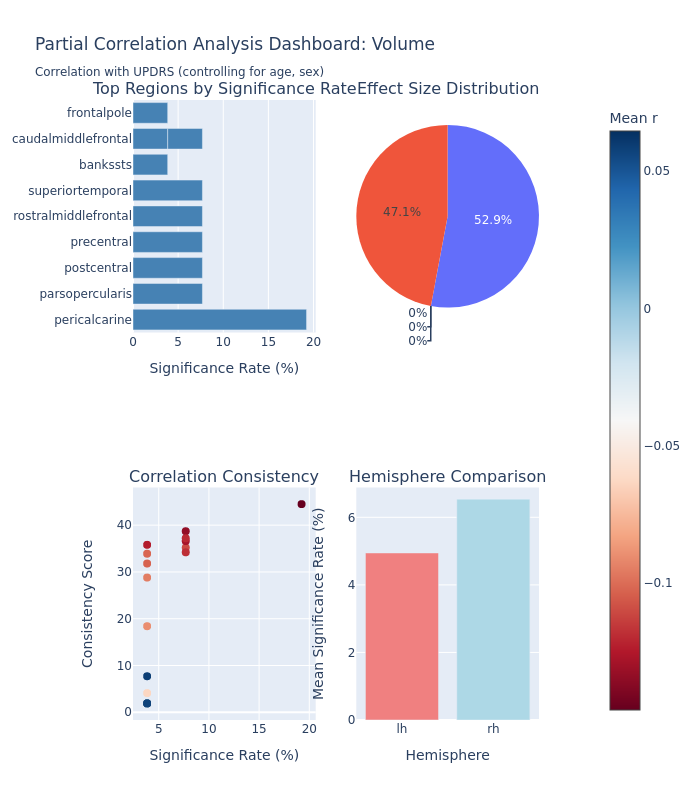


📋 Displaying top results table for volume...


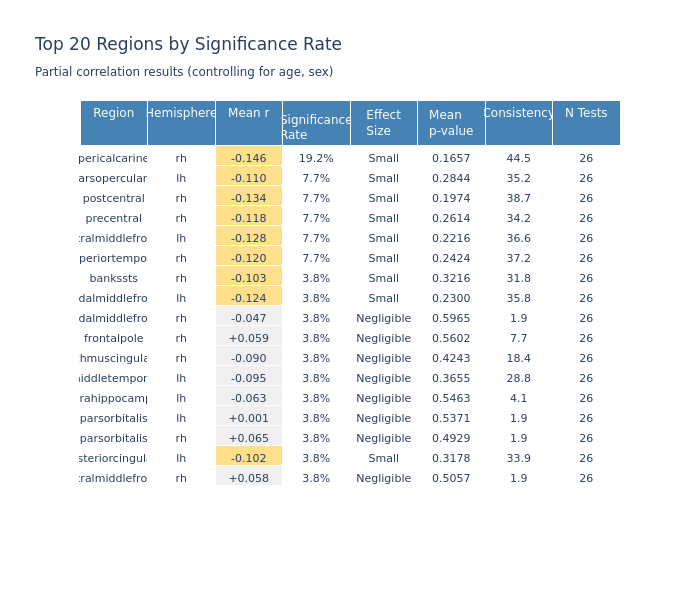


📝 Generating report for volume...
Error generating report: 'ascii' codec can't encode character '\u2022' in position 246: ordinal not in range(128)
✅ Report saved to partial_correlation/reports/{metric}_partial_correlation_longitudinal_report.txt

📊 QUICK SUMMARY FOR VOLUME
------------------------------
Regions analyzed: 17
Significant regions: 17
Mean significance rate: 5.9%
Median correlation: -0.102
Top region: pericalcarine (rh) (19.2%)

🎉 ANALYSIS COMPLETE!
--------------------
✅ Successfully analyzed 1 / 1 metrics
📁 Results saved in partial_correlation/ directory
🎨 Interactive visualizations created and displayed
📝 Detailed reports generated


In [8]:
# Enhanced single metric analysis
volume_results = run_complete_partial_correlation_analysis(
    metrics="volume",
    cohort_df=df_clinical,
    hemisphere=True,
    alpha=0.05,
    correction_method=None,
    force=False,
)

# Access results
significance_volume_df = volume_results["volume"]["significance_df"]
summary_volume = volume_results["volume"]["summary"]
visualizations_volume = volume_results["volume"]["visualizations"]


## Cortical thickness


🧠 COMPLETE PARTIAL CORRELATION ANALYSIS
📊 Analyzing 1 metric(s): thickness
🎯 Significance threshold: α = 0.05
🔧 Multiple comparison correction: None
🌐 Hemisphere analysis: Enabled

🔬 ANALYSIS 1/1: THICKNESS
----------------------------------------

🧠 Enhanced Partial Correlation Analysis for THICKNESS

📊 Step 1: Loading baseline data for thickness...
📁 Loading cached baseline data for thickness...
📁 Loading cached baseline data for thickness...


✅ Merged baseline and next visit data with shape: (219336, 22)
✅ Computed change for thickness with shape: (219336, 23)
🔄 Renaming columns for clarity...
✅ Loaded 219336 baseline records

🧮 Step 2: Computing partial correlations...
📁 Loading cached partial correlation results for thickness...
✅ Computed 1924 partial correlations

📊 Step 3: Computing significance statistics...
📊 Computing significance statistics for 1924 correlations...
🔄 Adding significance indicators...
🔄 Categorizing effect sizes...
Categorized 74 correlation coefficients into effect size categories
✅ Computed significance statistics for 74 regions
✅ Computed significance for 74 regions

💾 Step 4: Saving results...
📁 Saved detailed results to partial_correlation/partial_correlation_longitudinal_thickness.csv

📈 Step 5: Summary Statistics
------------------------------
Total regions analyzed: 74
Regions with significant correlations: 6
Mean significance rate: 0.6%

✅ Analysis complete! Found 6 regions with significant

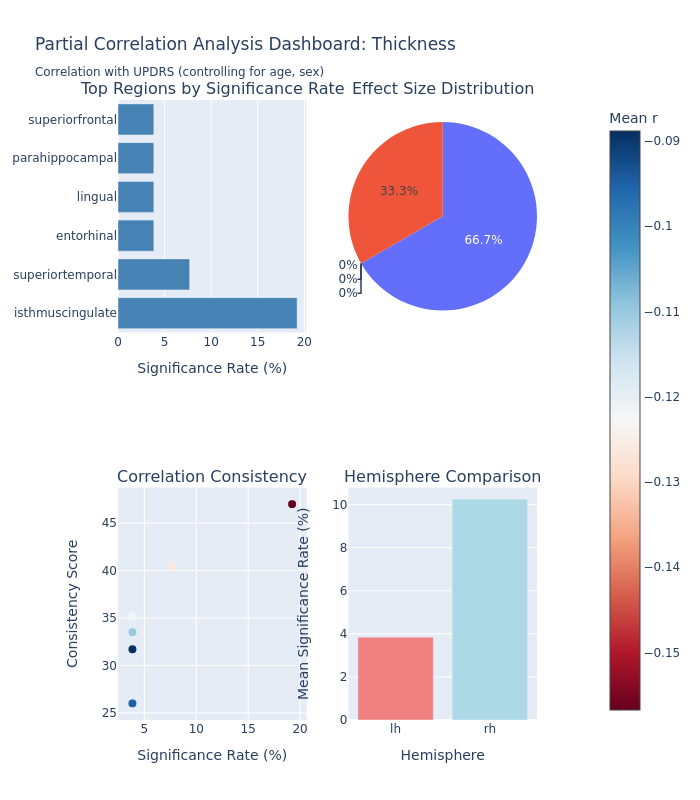


📋 Displaying top results table for thickness...


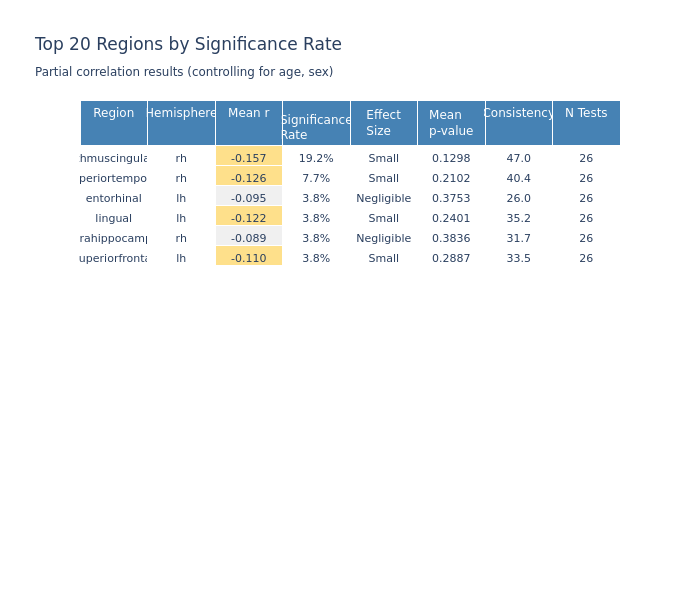


📝 Generating report for thickness...
Error generating report: 'ascii' codec can't encode character '\u2022' in position 249: ordinal not in range(128)
✅ Report saved to partial_correlation/reports/{metric}_partial_correlation_longitudinal_report.txt

📊 QUICK SUMMARY FOR THICKNESS
------------------------------
Regions analyzed: 6
Significant regions: 6
Mean significance rate: 7.1%
Median correlation: -0.116
Top region: isthmuscingulate (rh) (19.2%)

🎉 ANALYSIS COMPLETE!
--------------------
✅ Successfully analyzed 1 / 1 metrics
📁 Results saved in partial_correlation/ directory
🎨 Interactive visualizations created and displayed
📝 Detailed reports generated


In [9]:
# Enhanced single metric analysis
thickness_results = run_complete_partial_correlation_analysis(
    metrics="thickness",
    cohort_df=df_clinical,
    hemisphere=True,
    alpha=0.05,
    correction_method=None,
    force=False,
)

# Access results
significance_thickness_df = thickness_results["thickness"]["significance_df"]
summary_thickness = thickness_results["thickness"]["summary"]
visualizations_thickness = thickness_results["thickness"]["visualizations"]


In [10]:
significance_thickness_df

,region,hemisphere,n_significant,proportion_significant,n_correlations,mean_r,std_r,min_r,max_r,mean_p,std_p,min_p,max_p,mean_n,min_n,max_n,effect_size_category,significance_rate,correlation_consistency
27,isthmuscingulate,rh,5,0.192308,26,-0.156739,0.039658,-0.218639,-0.071990,0.129776,0.112771,0.021144,0.452745,114.0,114,114,Small,19.230769,47.0
67,superiortemporal,rh,2,0.076923,26,-0.126111,0.033956,-0.226485,-0.091592,0.210183,0.087748,0.016834,0.339038,114.0,114,114,Small,7.692308,40.4
14,entorhinal,lh,1,0.038462,26,-0.094830,0.049240,-0.230384,0.001336,0.375272,0.227815,0.014991,0.988899,114.0,114,114,Negligible,3.846154,26.0
32,lingual,lh,1,0.038462,26,-0.122177,0.040982,-0.189652,-0.021944,0.240112,0.183969,0.046193,0.819178,114.0,114,114,Small,3.846154,35.2
41,parahippocampal,rh,1,0.038462,26,-0.088839,0.035889,-0.211245,-0.046901,0.383567,0.159582,0.026042,0.624976,114.0,114,114,Negligible,3.846154,31.7
62,superiorfrontal,lh,1,0.038462,26,-0.110036,0.040498,-0.192855,-0.025414,0.288724,0.201329,0.042568,0.791188,114.0,114,114,Small,3.846154,33.5


## Cortical surface area


🧠 COMPLETE PARTIAL CORRELATION ANALYSIS
📊 Analyzing 1 metric(s): area
🎯 Significance threshold: α = 0.05
🔧 Multiple comparison correction: None
🌐 Hemisphere analysis: Enabled

🔬 ANALYSIS 1/1: AREA
----------------------------------------

🧠 Enhanced Partial Correlation Analysis for AREA

📊 Step 1: Loading baseline data for area...
📁 Loading cached baseline data for area...
📁 Loading cached baseline data for area...
✅ Merged baseline and next visit data with shape: (219336, 22)
✅ Computed change for area with shape: (219336, 23)
🔄 Renaming columns for clarity...
✅ Loaded 219336 baseline records

🧮 Step 2: Computing partial correlations...
📁 Loading cached partial correlation results for area...
✅ Computed 1924 partial correlations

📊 Step 3: Computing significance statistics...
📊 Computing significance statistics for 1924 correlations...
🔄 Adding significance indicators...
🔄 Categorizing effect sizes...
Categorized 74 correlation coefficients into effect size categories
✅ Computed sign

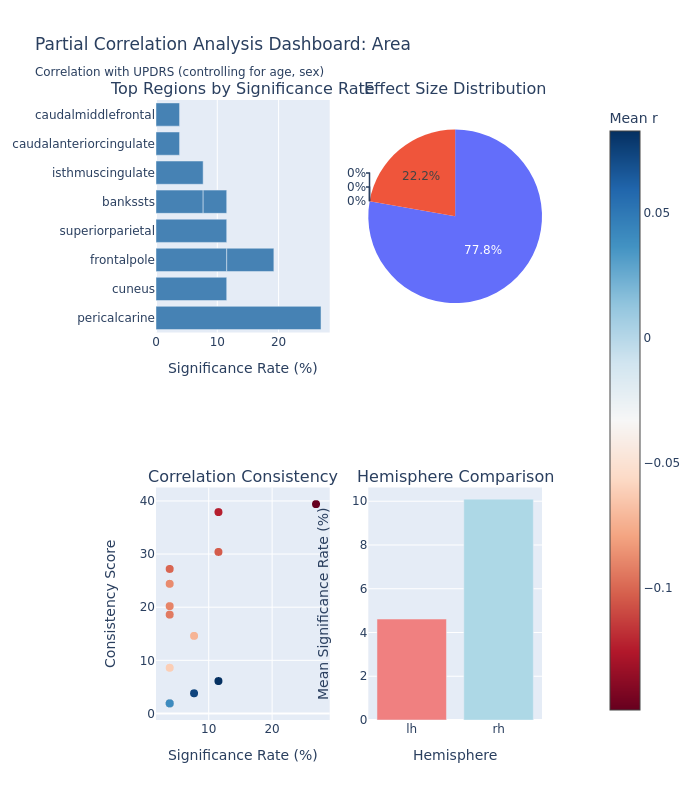


📋 Displaying top results table for area...


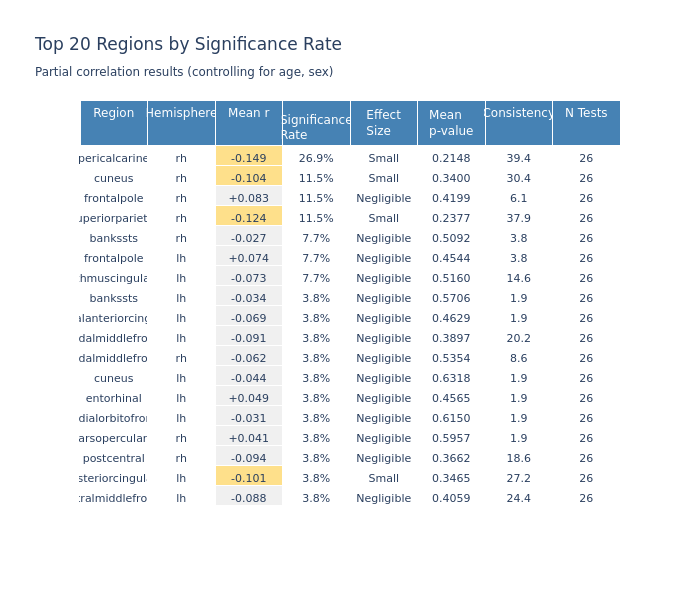


📝 Generating report for area...
Error generating report: 'ascii' codec can't encode character '\u2022' in position 244: ordinal not in range(128)
✅ Report saved to partial_correlation/reports/{metric}_partial_correlation_longitudinal_report.txt

📊 QUICK SUMMARY FOR AREA
------------------------------
Regions analyzed: 18
Significant regions: 18
Mean significance rate: 7.1%
Median correlation: -0.066
Top region: pericalcarine (rh) (26.9%)

🎉 ANALYSIS COMPLETE!
--------------------
✅ Successfully analyzed 1 / 1 metrics
📁 Results saved in partial_correlation/ directory
🎨 Interactive visualizations created and displayed
📝 Detailed reports generated


In [11]:
# Enhanced single metric analysis
area_results = run_complete_partial_correlation_analysis(
    metrics="area",
    cohort_df=df_clinical,
    hemisphere=True,
    alpha=0.05,
    correction_method=None,
    force=False,
)

# Access results
significance_area_df = area_results["area"]["significance_df"]
summary_area = area_results["area"]["summary"]
visualizations_area = area_results["area"]["visualizations"]


In [12]:
significance_area_df

,region,hemisphere,n_significant,proportion_significant,n_correlations,mean_r,std_r,min_r,max_r,mean_p,std_p,min_p,max_p,mean_n,min_n,max_n,effect_size_category,significance_rate,correlation_consistency
49,pericalcarine,rh,7,0.269231,26,-0.149070,0.071720,-0.268048,-0.015448,0.214812,0.258367,0.004450,0.872158,114.0,114,114,Small,26.923077,39.4
11,cuneus,rh,3,0.115385,26,-0.104102,0.052759,-0.213771,-0.019009,0.339970,0.241851,0.024270,0.843030,114.0,114,114,Small,11.538462,30.4
17,frontalpole,rh,3,0.115385,26,0.082783,0.082225,-0.067038,0.247890,0.419909,0.306361,0.008711,0.977723,114.0,114,114,Negligible,11.538462,6.1
65,superiorparietal,rh,3,0.115385,26,-0.123866,0.044285,-0.221140,-0.014277,0.237703,0.185544,0.019678,0.881771,114.0,114,114,Small,11.538462,37.9
5,bankssts,rh,2,0.076923,26,-0.027231,0.094329,-0.197124,0.177377,0.509175,0.308704,0.038106,0.994653,114.0,114,114,Negligible,7.692308,3.8
16,frontalpole,lh,2,0.076923,26,0.073834,0.074888,-0.072577,0.237015,0.454372,0.288148,0.012258,0.914731,114.0,114,114,Negligible,7.692308,3.8
26,isthmuscingulate,lh,2,0.076923,26,-0.073264,0.057434,-0.248656,-0.017057,0.516013,0.264548,0.008499,0.858973,114.0,114,114,Negligible,7.692308,14.6
4,bankssts,lh,1,0.038462,26,-0.033862,0.073218,-0.241528,0.060841,0.570639,0.247476,0.010656,0.962919,114.0,114,114,Negligible,3.846154,1.9
6,caudalanteriorcingulate,lh,1,0.038462,26,-0.069064,0.071071,-0.230467,0.094951,0.462910,0.280735,0.014954,0.923381,114.0,114,114,Negligible,3.846154,1.9
8,caudalmiddlefrontal,lh,1,0.038462,26,-0.090691,0.057469,-0.187286,0.041330,0.389664,0.242638,0.049034,0.853801,114.0,114,114,Negligible,3.846154,20.2


## Subcortical volume


🧠 COMPLETE PARTIAL CORRELATION ANALYSIS
📊 Analyzing 1 metric(s): subcortical_volume
🎯 Significance threshold: α = 0.05
🔧 Multiple comparison correction: None
🌐 Hemisphere analysis: Disabled

🔬 ANALYSIS 1/1: SUBCORTICAL_VOLUME
----------------------------------------

🧠 Enhanced Partial Correlation Analysis for SUBCORTICAL_VOLUME

📊 Step 1: Loading baseline data for subcortical_volume...
📁 Loading cached baseline data for subcortical_volume...
📁 Loading cached baseline data for subcortical_volume...


✅ Merged baseline and next visit data with shape: (189696, 21)
✅ Computed change for subcortical_volume with shape: (189696, 22)
🔄 Renaming columns for clarity...
✅ Loaded 189696 baseline records

🧮 Step 2: Computing partial correlations...
📁 Loading cached partial correlation results for subcortical_volume...
✅ Computed 1486 partial correlations

📊 Step 3: Computing significance statistics...
📊 Computing significance statistics for 1486 correlations...
🔄 Adding significance indicators...
🔄 Categorizing effect sizes...
Categorized 59 correlation coefficients into effect size categories
✅ Computed significance statistics for 59 regions
✅ Computed significance for 59 regions

💾 Step 4: Saving results...
📁 Saved detailed results to partial_correlation/partial_correlation_longitudinal_subcortical_volume.csv

📈 Step 5: Summary Statistics
------------------------------
Total regions analyzed: 59
Regions with significant correlations: 11
Mean significance rate: 3.3%

✅ Analysis complete! Foun

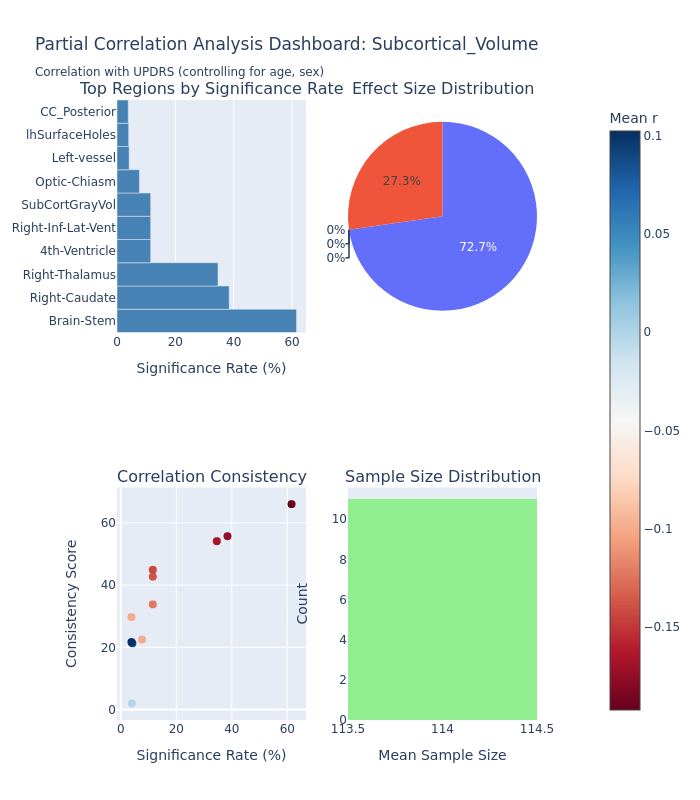


📋 Displaying top results table for subcortical_volume...


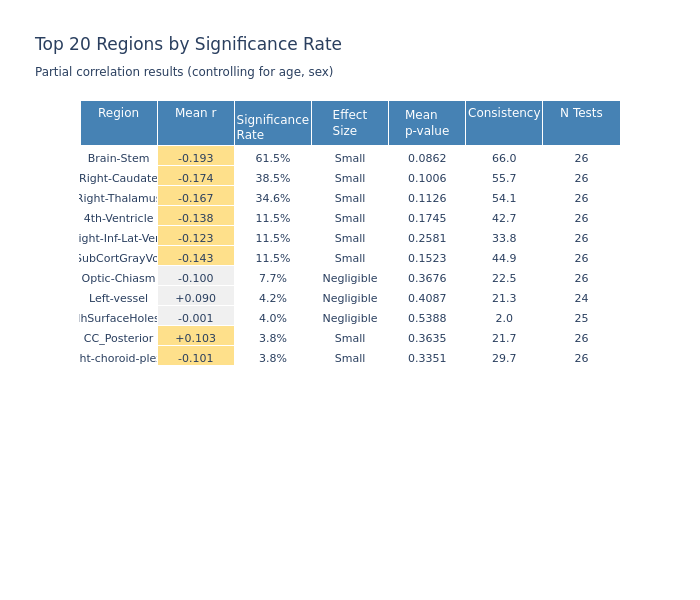


📝 Generating report for subcortical_volume...
Error generating report: 'ascii' codec can't encode character '\u2022' in position 258: ordinal not in range(128)
✅ Report saved to partial_correlation/reports/{metric}_partial_correlation_longitudinal_report.txt

📊 QUICK SUMMARY FOR SUBCORTICAL_VOLUME
------------------------------
Regions analyzed: 11
Significant regions: 11
Mean significance rate: 17.5%
Median correlation: -0.123
Top region: Brain-Stem (61.5%)

🎉 ANALYSIS COMPLETE!
--------------------
✅ Successfully analyzed 1 / 1 metrics
📁 Results saved in partial_correlation/ directory
🎨 Interactive visualizations created and displayed
📝 Detailed reports generated


In [13]:
# Enhanced single metric analysis
subcortical_volume_results = run_complete_partial_correlation_analysis(
    metrics="subcortical_volume",
    cohort_df=df_clinical,
    hemisphere=False,
    alpha=0.05,
    correction_method=None,
    force=False,
)

# Access results
significance_subcortical_volume_df = subcortical_volume_results["subcortical_volume"][
    "significance_df"
]
summary_subcortical_volume = subcortical_volume_results["subcortical_volume"]["summary"]
visualizations_subcortical_volume = subcortical_volume_results["subcortical_volume"][
    "visualizations"
]
